# RoamCeylon — ML Recommendation Model Training
**Dataset:** smote_balanced_dataset.csv (4,442 rows × 61 columns)

**Task:** Binary classification — predict positive user-destination engagement

## Task Coverage
| Task | Status |
|---|---|
| Task 2 — Model Selection Confirmation | XGBoost as Content-Based primary model |
| Task 3 — Train First ML Model | XGBoost (primary) + LR + RF (comparison) |

## Pipeline
1. Load & verify SMOTE dataset
2. Drop leakage feature
3. Correlation analysis
4. Verify SMOTE values
5. Train/Val/Test split
6. Train XGBoost (primary content-based model)
7. Train Logistic Regression (comparison)
8. Train Random Forest (comparison)
9. Compare all models
10. Final test evaluation + save model

## Step 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('smote_balanced_dataset.csv')

print(f'Shape: {df.shape}')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nBalance ratio: {df["label"].value_counts()[1] / df["label"].value_counts()[0]:.2f}')

Shape: (4442, 55)
Null values: 0

Label distribution:
label
0    2221
1    2221
Name: count, dtype: int64

Balance ratio: 1.00


## Step 2 — Drop Features Before Training

### 2A. Drop leakage features
**`recency_weight`** — This is `exp(-0.05 × days_ago)`. It encodes *when* the event happened,
not *what kind* of user or destination it is. In production you never know the event timestamp
before making a recommendation. It should be used as `sample_weight` during training, not as
an input feature. Keep it separately for that purpose.

**`weighted_engagement_norm`** and **`booked_users_norm`** — These are destination-level
aggregations computed from the same event log the labels came from. They partially encode
the label signal directly. Safe to keep for offline training but flag for monitoring in production.

In [3]:
# Separate recency_weight BEFORE dropping — use as sample_weight during training
sample_weights = df['recency_weight'].values
print(f'Sample weights range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')

# Features to drop with reasons
DROP_LEAKAGE = [
    'recency_weight',      # use as sample_weight, not input feature
]

# Note: travel_pace_preference (0.00473) and cat_cvr_* are borderline —
# keeping them since they're close to threshold and have semantic meaning

print(f'\nDropping {len(DROP_LEAKAGE)} features:')
for d in DROP_LEAKAGE:
    print(f'  - {d}')

Sample weights range: 0.2233 — 1.0000

Dropping 1 features:
  - recency_weight


In [4]:
# Apply drops
df_clean = df.drop(columns=DROP_LEAKAGE, errors='ignore')

X = df_clean.drop('label', axis=1)
y = df_clean['label']

print(f'Shape after dropping: {X.shape}')
print(f'Features remaining: {X.shape[1]}')
print(f'\nRemaining columns:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Shape after dropping: (4442, 53)
Features remaining: 53

Remaining columns:
   1. interest_sightseeing
   2. interest_culture
   3. interest_history
   4. interest_nature
   5. interest_beach
   6. interest_adventure
   7. interest_relaxation
   8. interest_strength
   9. booking_rate
  10. save_rate
  11. exploration_rate
  12. conversion_rate
  13. travel_pace_preference
  14. category_loyalty_score
  15. user_unique_dests
  16. user_active_days
  17. feedback_positivity_rate
  18. fb_rate_sightseeing
  19. fb_rate_culture
  20. fb_rate_history
  21. fb_rate_nature
  22. fb_rate_beach
  23. fb_rate_adventure
  24. dest_feedback_rate
  25. dest_pos_feedback_count
  26. dest_total_feedback
  27. cat_usage_share_sightseeing
  28. cat_usage_share_culture
  29. cat_usage_share_history
  30. cat_usage_share_nature
  31. cat_usage_share_beach
  32. cat_usage_share_adventure
  33. cat_recency_sightseeing
  34. cat_recency_culture
  35. cat_recency_history
  36. cat_recency_nature
  37. cat_r

## Step 3 — Correlation Analysis

=== Feature correlation with label (top 20) ===
feedback_positivity_rate    0.342937
click_frequency             0.301275
fb_rate_culture             0.273851
fb_rate_nature              0.268600
fb_rate_sightseeing         0.252999
fb_rate_history             0.248229
fb_rate_beach               0.245261
exploration_rate            0.213473
fb_rate_adventure           0.171294
dest_feedback_rate          0.147614
dest_pos_feedback_count     0.142959
travel_pace_preference      0.134560
save_rate                   0.123422
conversion_rate             0.114200
user_item_affinity          0.097779
cat_usage_share_nature      0.095690
weighted_engagement_norm    0.076090
cat_recency_beach           0.071845
cat_usage_share_history     0.071075
cat_usage_share_culture     0.067043


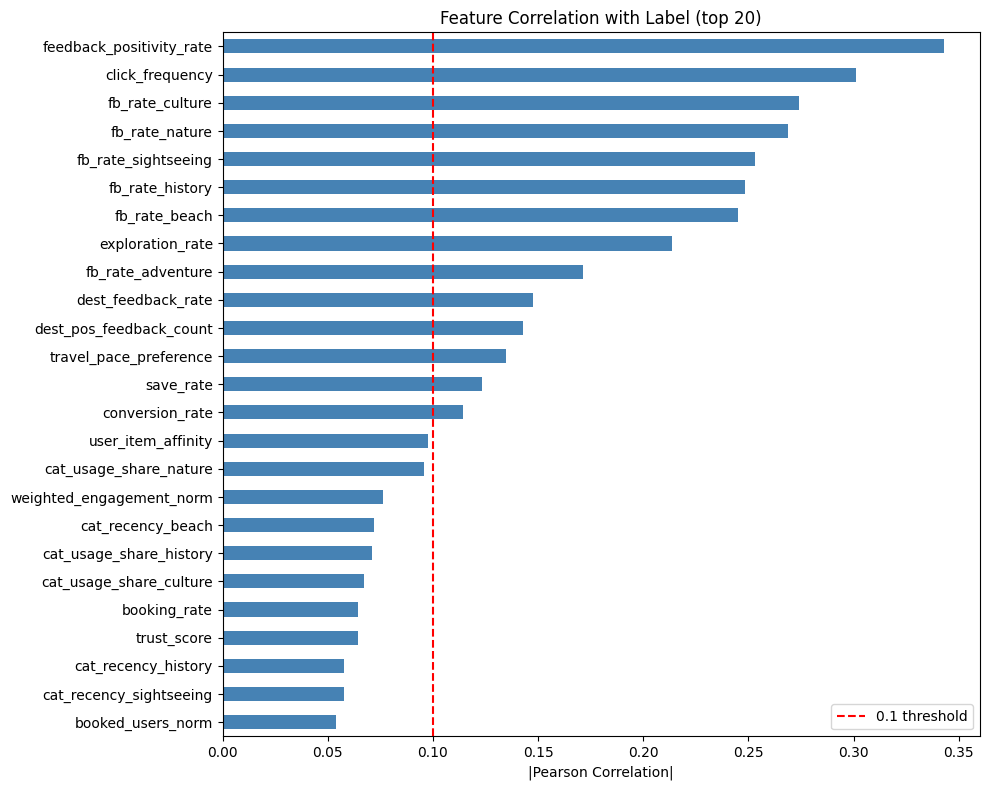

Saved: correlation_with_label.png


In [5]:
# ── 3A. Correlation with label ──────────────────────────────────────────────
label_corr = X.corrwith(y).abs().sort_values(ascending=False)

print('=== Feature correlation with label (top 20) ===')
print(label_corr.head(20).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
label_corr.head(25).plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
ax.set_title('Feature Correlation with Label (top 20)')
ax.set_xlabel('|Pearson Correlation|')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('correlation_with_label.png', dpi=150)
plt.show()
print('Saved: correlation_with_label.png')

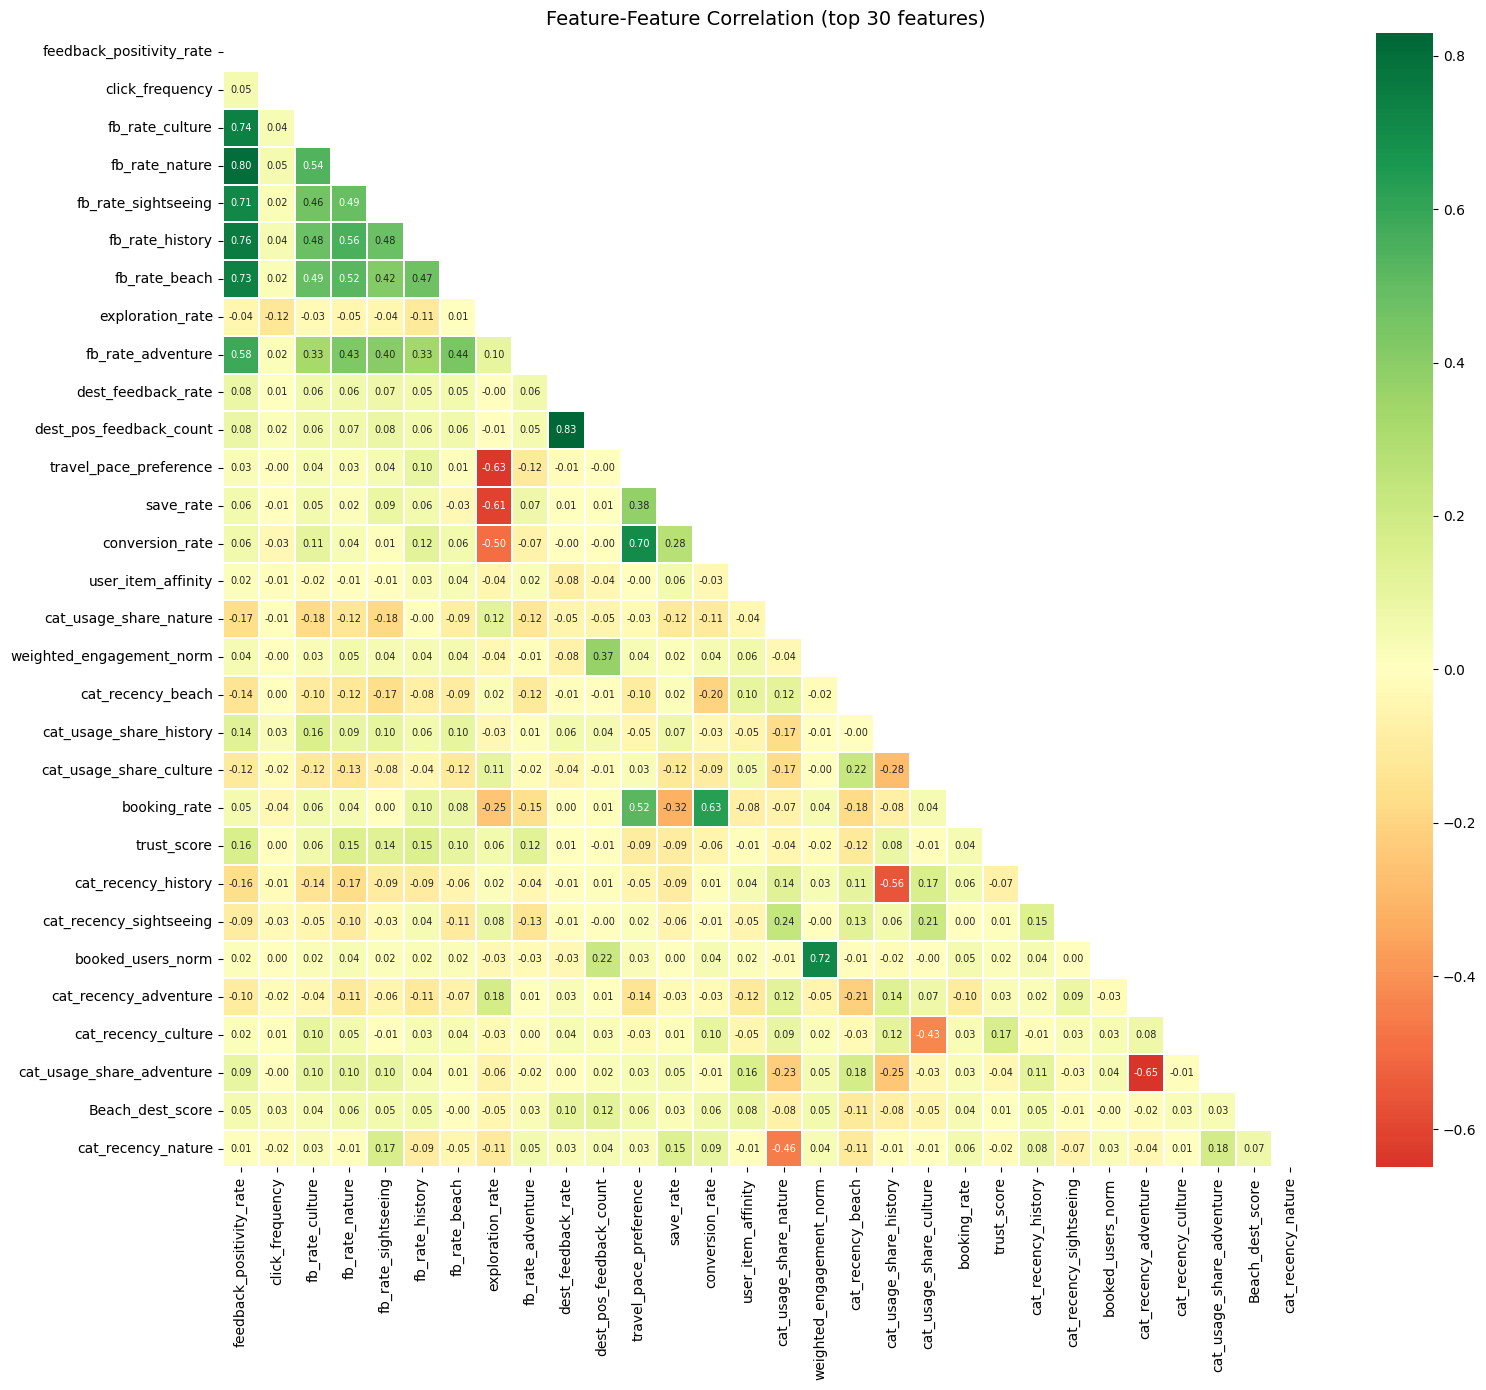

Saved: feature_correlation_heatmap.png


In [6]:
# ── 3B. Feature-feature correlation heatmap (top 30 by label corr) ─────────
top_features = label_corr.head(30).index.tolist()

fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = X[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    annot_kws={'size': 7},
    linewidths=0.3,
)
ax.set_title('Feature-Feature Correlation (top 30 features)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: feature_correlation_heatmap.png')

In [7]:
# ── 3C. High correlation pairs check ───────────────────────────────────────
print('=== High correlation pairs (|corr| > 0.85) ===')
corr_abs = X.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85
]
if high_pairs:
    for c1, c2, v in sorted(high_pairs, key=lambda x: x[2], reverse=True):
        print(f'  {v:.4f}  {c1}  <->  {c2}')
else:
    print('  No high correlation pairs remaining — clean!')

=== High correlation pairs (|corr| > 0.85) ===
  No high correlation pairs remaining — clean!


## Step 4 — Verify SMOTE Feature Values Are Correct

SMOTE generates synthetic samples by interpolating between real neighbors.
For continuous features this is valid. The check below confirms all features
stay within their expected bounds after SMOTE.

In [8]:
print('=== SMOTE value verification ===')
print(f'\nSMOTE rows (label=0 synthetic): {(y==0).sum()}')
print(f'Original rows (label=1):        {(y==1).sum()}')

# Verify all features are in valid range
EXPECTED_RANGES = {
    'interest_sightseeing': (0.0, 1.0),
    'interest_culture':     (0.0, 1.0),
    'interest_history':     (0.0, 1.0),
    'interest_nature':      (0.0, 1.0),
    'interest_beach':       (0.0, 1.0),
    'interest_adventure':   (0.0, 1.0),
    'interest_relaxation':  (0.0, 1.0),
    'feedback_positivity_rate': (0.0, 1.0),
    'aggregate_feedback_rating': (0.0, 1.0),
    'click_frequency':      (0.0, 2.0),
    'trust_score':          (0.0, 1.0),
}

print('\nRange validation:')
all_ok = True
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in X.columns:
        continue
    actual_min = X[col].min()
    actual_max = X[col].max()
    ok = actual_min >= lo and actual_max <= hi
    status = '✅' if ok else '⚠️'
    if not ok:
        all_ok = False
    print(f'  {status} {col}: [{actual_min:.4f}, {actual_max:.4f}] expected [{lo}, {hi}]')

print(f'\nAll values valid: {all_ok}')

# Confirm SMOTE did not create impossible values
# Sample 5 synthetic rows and show key features
print('\nSample synthetic rows (label=0, SMOTE generated):')
synthetic = df_clean[y==0].head(3)
key_cols = ['feedback_positivity_rate', 'click_frequency',
            'aggregate_feedback_rating', 'trust_score',
            'interest_beach', 'interest_history', 'label']
print(synthetic[key_cols].to_string())

=== SMOTE value verification ===

SMOTE rows (label=0 synthetic): 2221
Original rows (label=1):        2221

Range validation:
  ✅ interest_sightseeing: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_culture: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_history: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_nature: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_beach: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_adventure: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ interest_relaxation: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ feedback_positivity_rate: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ aggregate_feedback_rating: [0.0000, 1.0000] expected [0.0, 1.0]
  ✅ click_frequency: [0.0000, 1.0000] expected [0.0, 2.0]
  ✅ trust_score: [0.3010, 0.8910] expected [0.0, 1.0]

All values valid: True

Sample synthetic rows (label=0, SMOTE generated):
   feedback_positivity_rate  click_frequency  aggregate_feedback_rating  trust_score  interest_beach  interest_history  label
0     

## Step 5 — Train / Validation / Test Split

Using stratified random split since SMOTE already broke temporal order.
70% train / 15% val / 15% test.

In [9]:
from sklearn.model_selection import train_test_split

# First split: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp, sw_train, sw_temp = train_test_split(
    X, y, sample_weights,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: val (15%) vs test (15%)
X_val, X_test, y_val, y_test, sw_val, sw_test = train_test_split(
    X_temp, y_temp, sw_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Train:      {X_train.shape[0]} rows  | label=1: {y_train.sum()} ({y_train.mean():.1%})')
print(f'Validation: {X_val.shape[0]} rows  | label=1: {y_val.sum()} ({y_val.mean():.1%})')
print(f'Test:       {X_test.shape[0]} rows  | label=1: {y_test.sum()} ({y_test.mean():.1%})')

Train:      3109 rows  | label=1: 1555 (50.0%)
Validation: 666 rows  | label=1: 333 (50.0%)
Test:       667 rows  | label=1: 333 (49.9%)


## Step 6 — Train Primary Model: XGBoost (Content-Based)

**Why XGBoost as the content-based model:**
- Handles non-linear relationships between user interests and destination features
- Automatically captures feature interactions (e.g. high beach interest + high Beach_dest_score)
- Works well at any dataset size — no minimum user count needed
- Does not require feature scaling unlike Logistic Regression
- Feature importance is interpretable



In [12]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    classification_report
)

[0]	validation_0-logloss:0.68126
[50]	validation_0-logloss:0.46886
[100]	validation_0-logloss:0.41073
[150]	validation_0-logloss:0.38823
[200]	validation_0-logloss:0.37817
[250]	validation_0-logloss:0.37275
[299]	validation_0-logloss:0.37287

=== XGBoost — Validation Results ===
ROC-AUC:  0.9127
AUC-PR:   0.9026
F1 Score: 0.8306

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       333
           1       0.83      0.83      0.83       333

    accuracy                           0.83       666
   macro avg       0.83      0.83      0.83       666
weighted avg       0.83      0.83      0.83       666



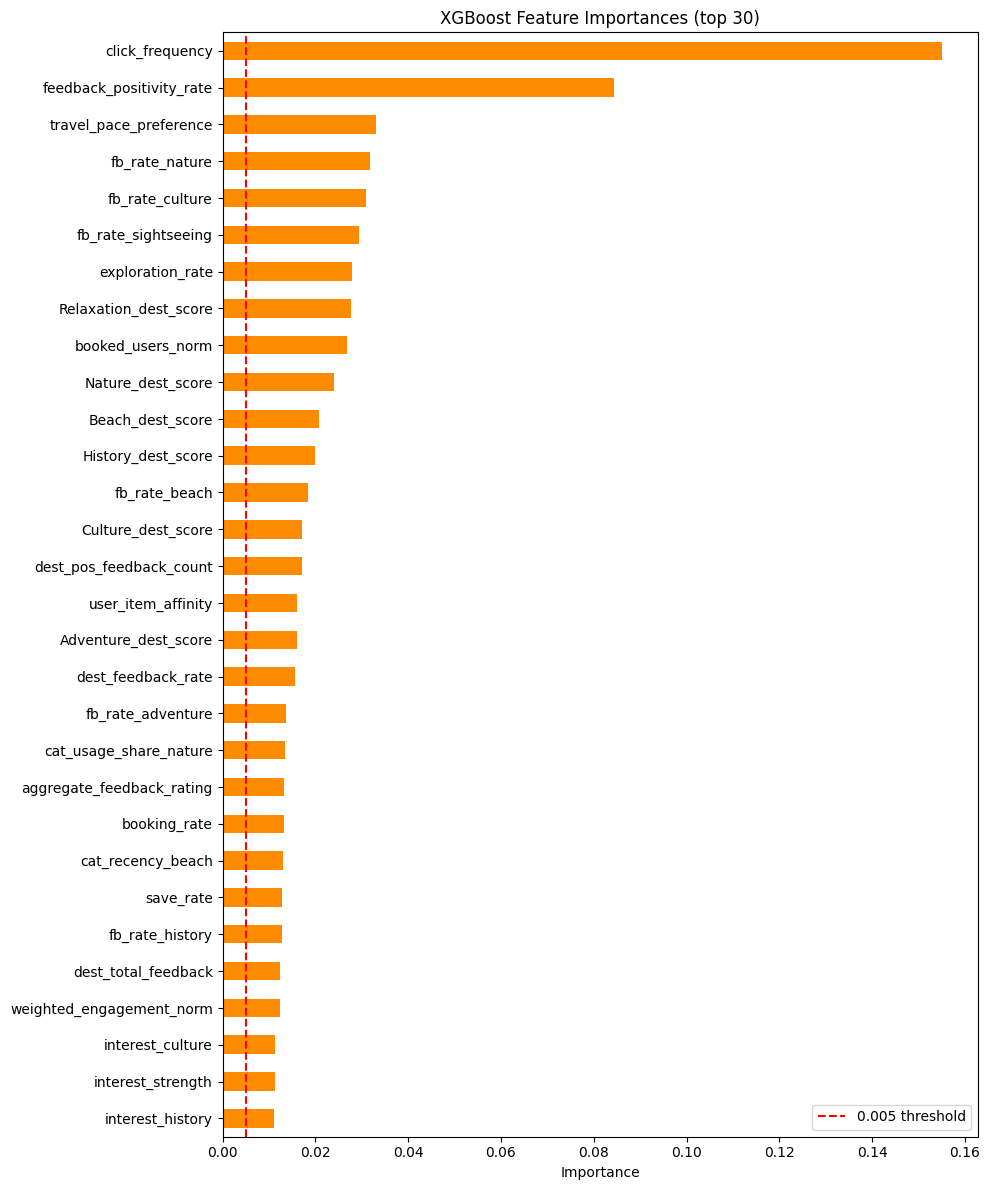

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    sample_weight=sw_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_val_pred_xgb = xgb.predict(X_val)
y_val_prob_xgb = xgb.predict_proba(X_val)[:, 1]

print('\n=== XGBoost — Validation Results ===')
print(f'ROC-AUC:  {roc_auc_score(y_val, y_val_prob_xgb):.4f}')
print(f'AUC-PR:   {average_precision_score(y_val, y_val_prob_xgb):.4f}')
print(f'F1 Score: {f1_score(y_val, y_val_pred_xgb):.4f}')
print(f'\n{classification_report(y_val, y_val_pred_xgb)}')

# XGBoost feature importance
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 12))
xgb_importance.head(30).plot(kind='barh', ax=ax, color='darkorange')
ax.axvline(x=0.005, color='red', linestyle='--', label='0.005 threshold')
ax.set_title('XGBoost Feature Importances (top 30)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

### 6B — Random Forest (Comparison)

In [22]:
# COMPARISON MODEL — Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Pass recency_weight as sample_weight — recent events matter more
rf.fit(X_train, y_train, sample_weight=sw_train)

# Evaluate on validation set
y_val_pred_rf = rf.predict(X_val)
y_val_prob_rf = rf.predict_proba(X_val)[:, 1]

print('=== Random Forest — Validation Results ===')
print(f'ROC-AUC:        {roc_auc_score(y_val, y_val_prob_rf):.4f}')
print(f'AUC-PR:         {average_precision_score(y_val, y_val_prob_rf):.4f}')
print(f'F1 Score:       {f1_score(y_val, y_val_pred_rf):.4f}')
print(f'\n{classification_report(y_val, y_val_pred_rf)}')

val_auc_rf = roc_auc_score(y_val, y_val_prob_rf)
print(f'RF Val AUC stored: {val_auc_rf:.4f}')

=== Random Forest — Validation Results ===
ROC-AUC:        0.8708
AUC-PR:         0.8790
F1 Score:       0.7779

              precision    recall  f1-score   support

           0       0.77      0.80      0.79       333
           1       0.79      0.76      0.78       333

    accuracy                           0.78       666
   macro avg       0.78      0.78      0.78       666
weighted avg       0.78      0.78      0.78       666

RF Val AUC stored: 0.8708


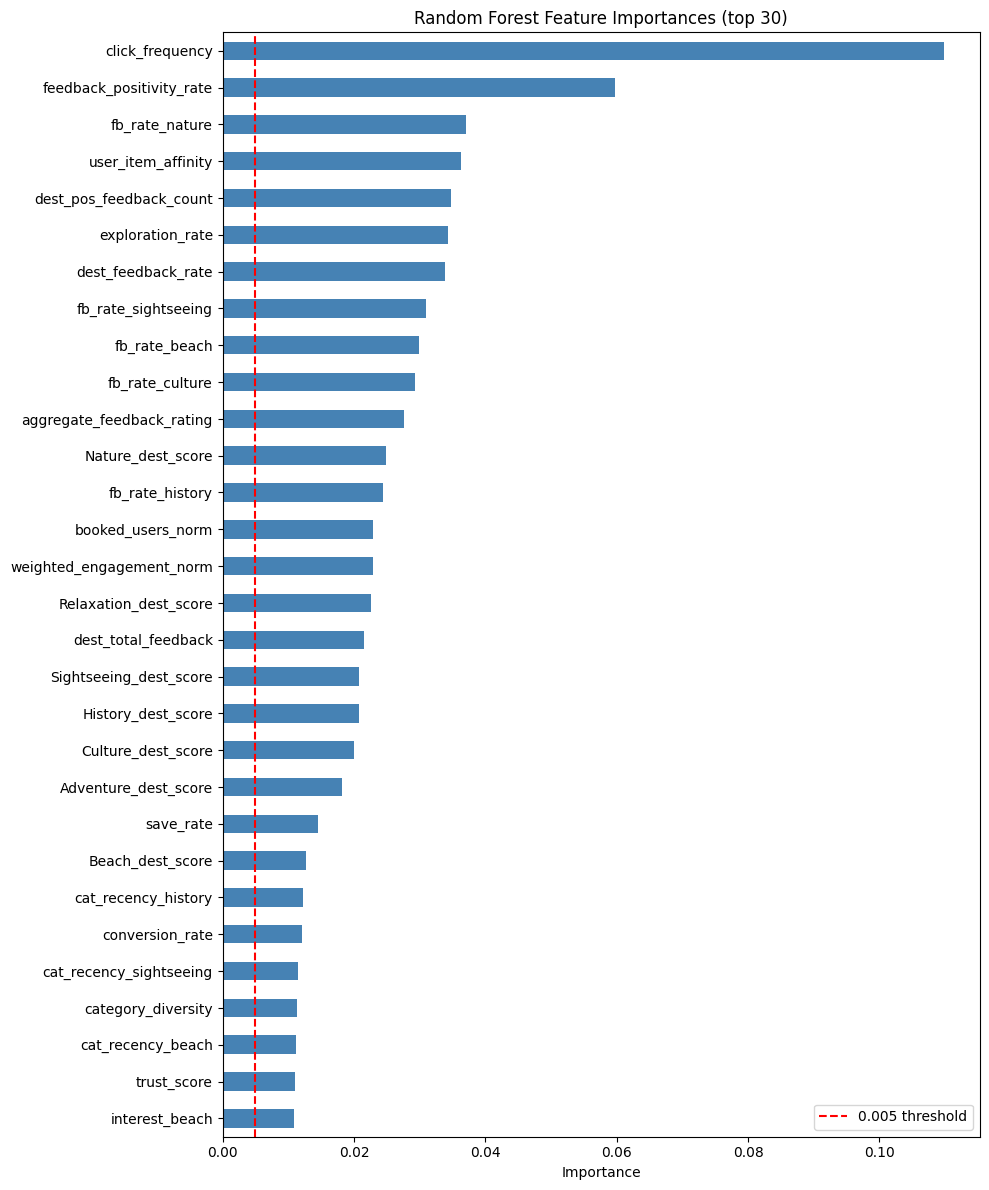

In [23]:
# Feature importance plot
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
rf_importance.head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=0.005, color='red', linestyle='--', label='0.005 threshold')
ax.set_title('Random Forest Feature Importances (top 30)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

### 6C — Logistic Regression (Comparison)

Included as comparison to show the content-based linear baseline.
Requires StandardScaler since it is sensitive to feature magnitude.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# COMPARISON MODEL — Logistic Regression (requires scaling)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train, sample_weight=sw_train)

y_val_pred_lr = lr.predict(X_val_sc)
y_val_prob_lr = lr.predict_proba(X_val_sc)[:, 1]

print('=== Logistic Regression (Comparison) — Validation Results ===')
print(f'ROC-AUC:  {roc_auc_score(y_val, y_val_prob_lr):.4f}')
print(f'AUC-PR:   {average_precision_score(y_val, y_val_prob_lr):.4f}')
print(f'F1 Score: {f1_score(y_val, y_val_pred_lr):.4f}')
print(f'\n{classification_report(y_val, y_val_pred_lr)}')

# Coefficients — what LR learned
coef_df = pd.DataFrame({
    'feature':     X.columns.tolist(),
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print('\nTop 5 positive signals:')
print(coef_df.head(5).to_string(index=False))
print('\nTop 5 negative signals:')
print(coef_df.tail(5).to_string(index=False))

=== Logistic Regression (Comparison) — Validation Results ===
ROC-AUC:  0.7723
AUC-PR:   0.7928
F1 Score: 0.6870

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       333
           1       0.70      0.68      0.69       333

    accuracy                           0.69       666
   macro avg       0.69      0.69      0.69       666
weighted avg       0.69      0.69      0.69       666


Top 5 positive signals:
                 feature  coefficient
         click_frequency     0.977960
feedback_positivity_rate     0.900850
      user_item_affinity     0.609091
weighted_engagement_norm     0.489703
      dest_feedback_rate     0.460608

Top 5 negative signals:
           feature  coefficient
  exploration_rate    -0.289927
  interest_history    -0.352295
History_dest_score    -0.418750
  Beach_dest_score    -0.420395
 Nature_dest_score    -0.431653


### 6D — Model Comparison Summary

              Model                  Role  ROC-AUC  F1 Score
  XGBoost (Primary) Content-Based Primary   0.9127    0.8306
      Random Forest            Comparison   0.8708    0.7779
Logistic Regression            Comparison   0.7723    0.6870


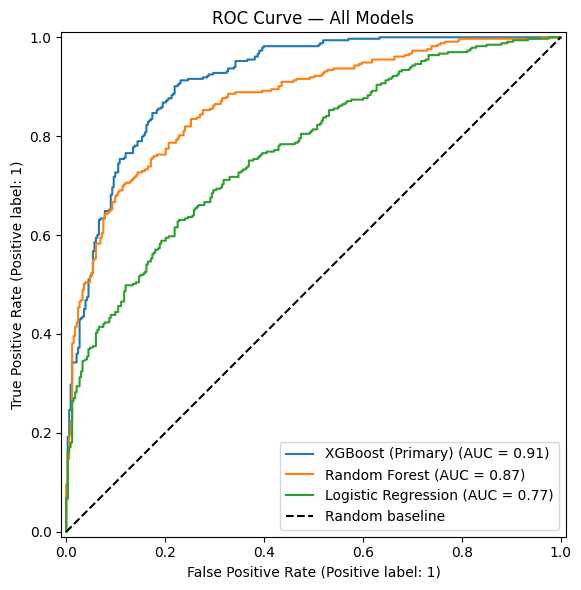

In [24]:
from sklearn.metrics import RocCurveDisplay

# Summary table
comparison = pd.DataFrame({
    'Model':   ['XGBoost (Primary)', 'Random Forest', 'Logistic Regression'],
    'Role':    ['Content-Based Primary', 'Comparison', 'Comparison'],
    'ROC-AUC': [
        round(roc_auc_score(y_val, y_val_prob_xgb), 4),
        round(roc_auc_score(y_val, y_val_prob_rf),  4),
        round(roc_auc_score(y_val, y_val_prob_lr),  4),
    ],
    'F1 Score': [
        round(f1_score(y_val, y_val_pred_xgb), 4),
        round(f1_score(y_val, y_val_pred_rf),  4),
        round(f1_score(y_val, y_val_pred_lr),  4),
    ],
})
print(comparison.to_string(index=False))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_val, y_val_prob_xgb, name='XGBoost (Primary)', ax=ax)
RocCurveDisplay.from_predictions(y_val, y_val_prob_rf,  name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_val, y_val_prob_lr,  name='Logistic Regression', ax=ax)
ax.plot([0,1],[0,1],'k--',label='Random baseline')
ax.set_title('ROC Curve — All Models')
ax.legend()
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150)
plt.show()

## Step 7 — Final Evaluation on Test Set

=== FINAL TEST RESULTS — XGBoost (Content-Based Primary) ===
ROC-AUC:  0.9043
AUC-PR:   0.8900
F1 Score: 0.8159

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       334
           1       0.80      0.83      0.82       333

    accuracy                           0.81       667
   macro avg       0.81      0.81      0.81       667
weighted avg       0.81      0.81      0.81       667



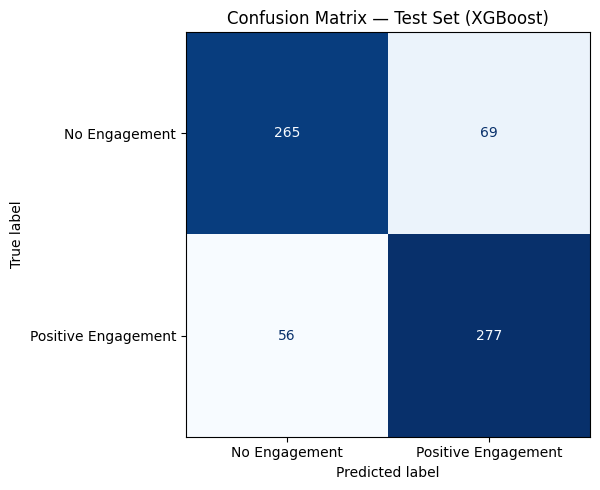

In [25]:
# Final evaluation — use XGBoost (primary model)
best_model = xgb

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print('=== FINAL TEST RESULTS — XGBoost (Content-Based Primary) ===')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_test_prob):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_test_prob):.4f}')
print(f'F1 Score: {f1_score(y_test, y_test_pred):.4f}')
print(f'\n{classification_report(y_test, y_test_pred)}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax,
                                         display_labels=['No Engagement','Positive Engagement'],
                                         colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set (XGBoost)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 8 — Save Model

In [26]:
import joblib

# Save model
joblib.dump(best_model, 'roamceylon_recommendation_model.pkl')

# Save feature list — must match at inference time
feature_list = X.columns.tolist()
pd.Series(feature_list).to_csv('model_features.csv', index=False, header=False)

print(f'Model saved: roamceylon_recommendation_model.pkl')
print(f'Features saved: model_features.csv ({len(feature_list)} features)')

# Inference example — how to use the model
print('\n=== Inference Example ===')
sample = X_test.iloc[:3]
probs = best_model.predict_proba(sample)[:, 1]
for i, (idx, row) in enumerate(sample.iterrows()):
    actual = y_test.iloc[i]
    status = '✅' if (probs[i] > 0.5) == actual else '❌'
    print(f'  Row {i}: P(positive engagement) = {probs[i]:.4f} | actual = {y_test.iloc[i]}')

Model saved: roamceylon_recommendation_model.pkl
Features saved: model_features.csv (53 features)

=== Inference Example ===
  Row 0: P(positive engagement) = 0.7909 | actual = 1
  Row 1: P(positive engagement) = 0.7645 | actual = 1
  Row 2: P(positive engagement) = 0.3981 | actual = 1
